In [50]:
import numpy as np 
import matplotlib.pyplot as plt
import mod as m 

In [51]:
date = '04-17-26'
path = f'Data/HighPressureTesting-{date}/'
ps = [363, 655, 1005]

arr = np.loadtxt(path+f"Clean-{ps[0]}Pa.txt")

## Check io

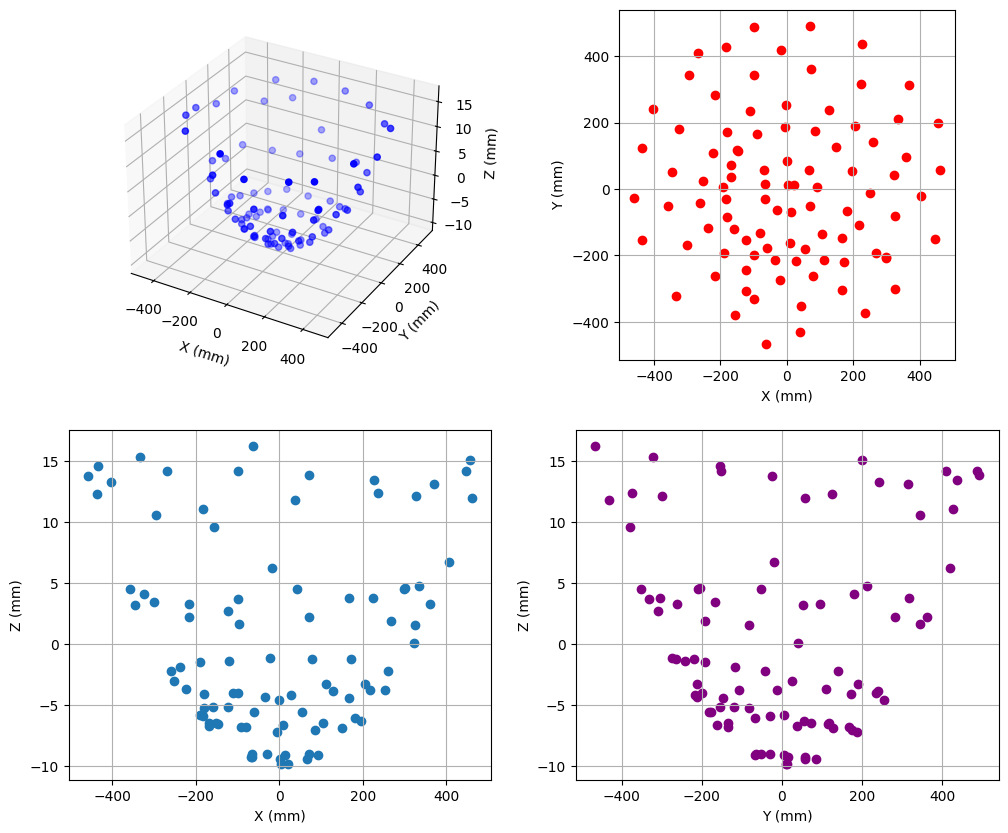

In [24]:
m.vis(arr[:,0], arr[:,1], arr[:,2], date)

In [25]:
Xg, Yg, Zg = m.surfacefit(arr[:,0], arr[:,1], arr[:,2])

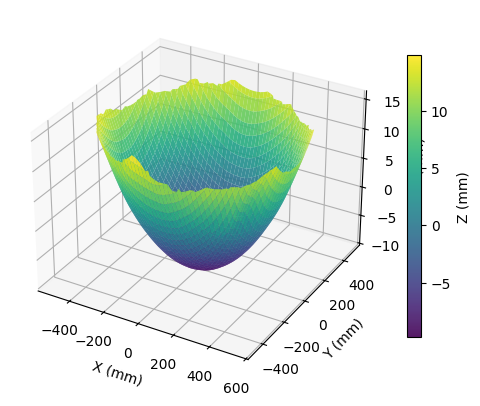

In [26]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(xs, Yg, Zg, cmap='viridis', edgecolor='none', alpha=0.9)
# ax.scatter(Xr, Yr, Zr, color='red', s=40)

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Z (mm)')

fig.colorbar(surf, ax=ax, shrink=0.6, label='Z (mm)')
plt.tight_layout()

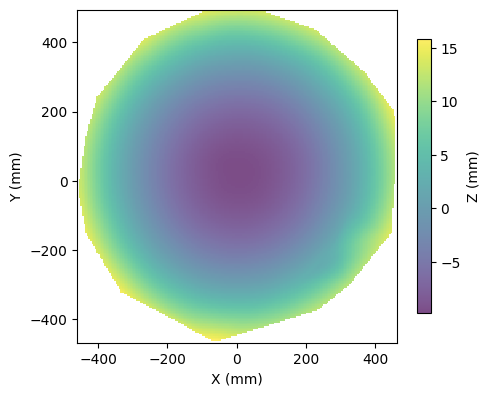

In [27]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

surf = ax.pcolormesh(Xg, Yg, Zg, cmap='viridis', edgecolor='none', alpha=0.7)
# ax.scatter(Xg, Yg, Zg, color='red')

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')

ax.set_aspect("equal")
fig.colorbar(surf, ax=ax, shrink=0.6, label='Z (mm)')
plt.tight_layout()

## Compress data 

In [57]:
fits = [] 
for p in ps: 
    arr = np.loadtxt(path+f"Clean-{p}Pa.txt")
    Xg, Yg, Zg = m.surfacefit(arr[:,0], arr[:,1], arr[:,2])
    fits.append({
        "p": p,
        "Xg": Xg,
        "Yg": Yg,
        "Zg": Zg
    })

In [58]:
def extract_cuts(Xg, Yg, Zg):
    ny, nx = Zg.shape
    ix = nx // 2   # middle column
    iy = ny // 2   # middle row

    x_xz = Xg[iy, :]
    z_xz = Zg[iy, :]

    y_yz = Yg[:, ix]
    z_yz = Zg[:, ix]

    return (x_xz, z_xz), (y_yz, z_yz)


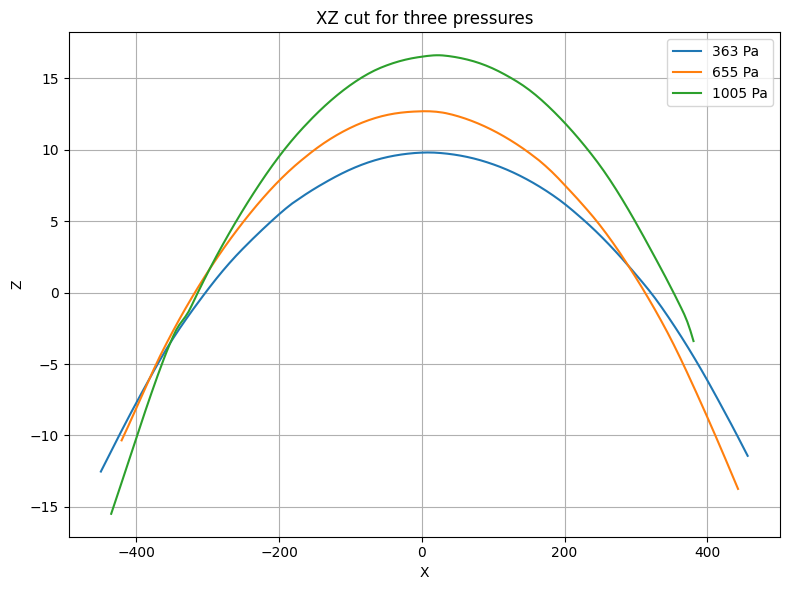

<Figure size 640x480 with 0 Axes>

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for fit in fits:
    p = fit["p"]
    Xg, Yg, Zg = fit["Xg"], fit["Yg"], fit["Zg"]

    # extract cuts
    (x_xz, z_xz), _ = extract_cuts(Xg, Yg, Zg)
    if p == 363: 
        plt.plot(x_xz, -1*z_xz, label=f"{p} Pa")
    else: 
        plt.plot(x_xz, z_xz, label=f"{p} Pa")

plt.xlabel("X")
plt.ylabel("Z")
plt.title("XZ cut for three pressures")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("figs/prelim-1.jpg")


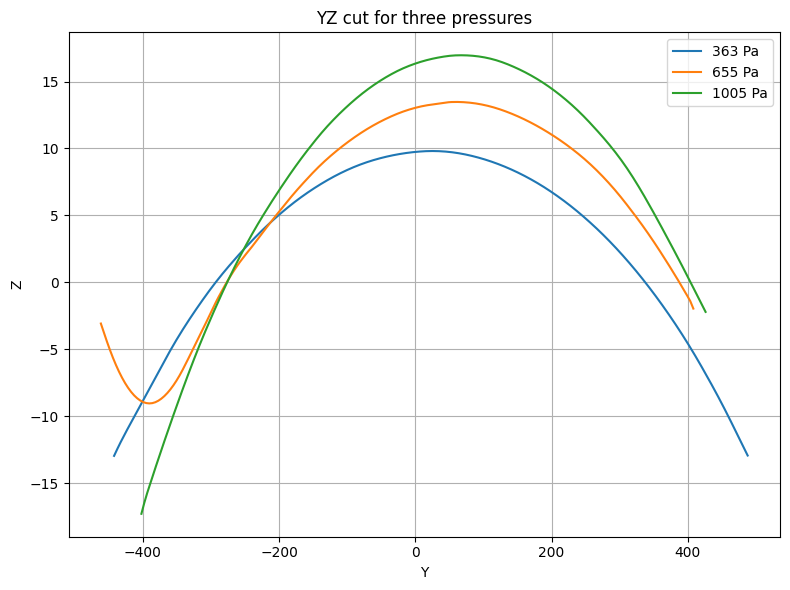

<Figure size 640x480 with 0 Axes>

In [72]:
plt.figure(figsize=(8,6))

for fit in fits:
    p = fit["p"]
    Xg, Yg, Zg = fit["Xg"], fit["Yg"], fit["Zg"]

    # extract cuts
    _, (y_yz, z_yz) = extract_cuts(Xg, Yg, Zg)
    if p == 363: 
        plt.plot(y_yz, -1*z_yz, label=f"{p} Pa")
    else: 
        plt.plot(y_yz, z_yz, label=f"{p} Pa")

plt.xlabel("Y")
plt.ylabel("Z")
plt.title("YZ cut for three pressures")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("figs/prelim-2.jpg")
